# Deep Learning Text Classifier — Sentiment Analysis (PyTorch)A multi-layer neural network for binary sentiment classification: TF-IDF vectorization, a `nn.Sequential` MLP with `Dropout` + `BatchNorm1d`, early stopping on validation loss, training-curve plots, and inference with confidence scores on genuinely unseen sentences.**Note on the dataset:** the training text is templated/synthetic (product-review style sentences built from a vocabulary of nouns and reason-phrases), generated because no internet dataset download was reachable in this environment. It gets the pipeline end-to-end correctly, but templated text is more separable than real reviews — the near-perfect training/validation accuracy below reflects that, not a claim the model would perform this well on real-world text. §6 tests it on hand-written, non-templated sentences as a more honest check.

In [ ]:
import numpy as npimport pandas as pdimport torchimport torch.nn as nnfrom torch.utils.data import TensorDataset, DataLoaderfrom sklearn.model_selection import train_test_splitfrom sklearn.feature_extraction.text import TfidfVectorizerfrom sklearn.metrics import classification_report, confusion_matrixtorch.manual_seed(42)np.random.seed(42)df = pd.read_csv('sentiment_reviews.csv')df.head()

## 1. Dataset860 labeled review-style sentences, roughly balanced between positive and negative.

In [ ]:
print(df.shape)print(df['label'].value_counts())

(860, 2)label1    4360    424Name: count, dtype: int64

## 2. Split BEFORE vectorizingRaw text is split into train/val/test first; `TfidfVectorizer` is fit only on the training sentences, so validation and test vocab statistics never leak into training.

In [ ]:
X_text = df['text'].valuesy = df['label'].valuesX_train_text, X_temp_text, y_train, y_temp = train_test_split(    X_text, y, test_size=0.3, random_state=42, stratify=y)X_val_text, X_test_text, y_val, y_test = train_test_split(    X_temp_text, y_temp, test_size=0.5, random_state=42, stratify=y_temp)print(f"Train: {len(X_train_text)}  Val: {len(X_val_text)}  Test: {len(X_test_text)}")

Train: 602  Val: 129  Test: 129

## 3. TF-IDF vectorization

In [ ]:
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1,2), min_df=2)X_train = vectorizer.fit_transform(X_train_text).toarray().astype(np.float32)X_val = vectorizer.transform(X_val_text).toarray().astype(np.float32)X_test = vectorizer.transform(X_test_text).toarray().astype(np.float32)print("Vocab size:", len(vectorizer.vocabulary_))

Vocab size: 498

## 4. Model: multi-layer NN with Dropout + BatchNorm

In [ ]:
def to_loader(X, y, batch_size=32, shuffle=False):    ds = TensorDataset(torch.tensor(X), torch.tensor(y, dtype=torch.float32))    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)train_loader = to_loader(X_train, y_train, shuffle=True)val_loader = to_loader(X_val, y_val)test_loader = to_loader(X_test, y_test)class TextClassifier(nn.Module):    def __init__(self, input_dim, hidden1=256, hidden2=64, dropout=0.4):        super().__init__()        self.net = nn.Sequential(            nn.Linear(input_dim, hidden1), nn.BatchNorm1d(hidden1), nn.ReLU(), nn.Dropout(dropout),            nn.Linear(hidden1, hidden2), nn.BatchNorm1d(hidden2), nn.ReLU(), nn.Dropout(dropout),            nn.Linear(hidden2, 1),        )    def forward(self, x):        return self.net(x).squeeze(-1)device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')model = TextClassifier(input_dim=X_train.shape[1]).to(device)criterion = nn.BCEWithLogitsLoss()optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)print(model)

TextClassifier(  (net): Sequential(    (0): Linear(in_features=498, out_features=256, bias=True)    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True)    (2): ReLU()    (3): Dropout(p=0.4, inplace=False)    (4): Linear(in_features=256, out_features=64, bias=True)    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True)    (6): ReLU()    (7): Dropout(p=0.4, inplace=False)    (8): Linear(in_features=64, out_features=1, bias=True)  ))

## 5. Train with early stopping on validation lossPatience of 6 epochs; the best-validation-loss weights are restored before final evaluation (shown truncated here — the full per-epoch log is in the console output when you run this cell).

In [ ]:
def evaluate(loader):    model.eval()    total_loss, correct, n = 0.0, 0, 0    with torch.no_grad():        for xb, yb in loader:            xb, yb = xb.to(device), yb.to(device)            logits = model(xb)            loss = criterion(logits, yb)            total_loss += loss.item() * xb.size(0)            preds = (torch.sigmoid(logits) > 0.5).float()            correct += (preds == yb).sum().item()            n += xb.size(0)    return total_loss / n, correct / nEPOCHS, PATIENCE = 60, 6best_val_loss, patience_counter, best_state = float('inf'), 0, Nonehistory = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}for epoch in range(1, EPOCHS + 1):    model.train()    running_loss, correct, n = 0.0, 0, 0    for xb, yb in train_loader:        xb, yb = xb.to(device), yb.to(device)        optimizer.zero_grad()        logits = model(xb)        loss = criterion(logits, yb)        loss.backward()        optimizer.step()        running_loss += loss.item() * xb.size(0)        preds = (torch.sigmoid(logits) > 0.5).float()        correct += (preds == yb).sum().item()        n += xb.size(0)    train_loss, train_acc = running_loss / n, correct / n    val_loss, val_acc = evaluate(val_loader)    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)    history['train_acc'].append(train_acc); history['val_acc'].append(val_acc)    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} acc={train_acc:.4f} "          f"| val_loss={val_loss:.4f} val_acc={val_acc:.4f}")    if val_loss < best_val_loss - 1e-4:        best_val_loss, patience_counter = val_loss, 0        best_state = {k: v.clone() for k, v in model.state_dict().items()}    else:        patience_counter += 1        if patience_counter >= PATIENCE:            print(f"Early stopping at epoch {epoch} (best val_loss={best_val_loss:.4f})")            breakmodel.load_state_dict(best_state)

Epoch 01 | train_loss=0.4040 acc=0.8904 | val_loss=0.6370 val_acc=1.0000Epoch 02 | train_loss=0.1455 acc=1.0000 | val_loss=0.4364 val_acc=1.0000...Epoch 46 | train_loss=0.0010 acc=1.0000 | val_loss=0.0003 val_acc=1.0000Epoch 47 | train_loss=0.0009 acc=1.0000 | val_loss=0.0003 val_acc=1.0000Early stopping at epoch 47 (best val_loss=0.0004)

## 6. Loss and accuracy convergence curves

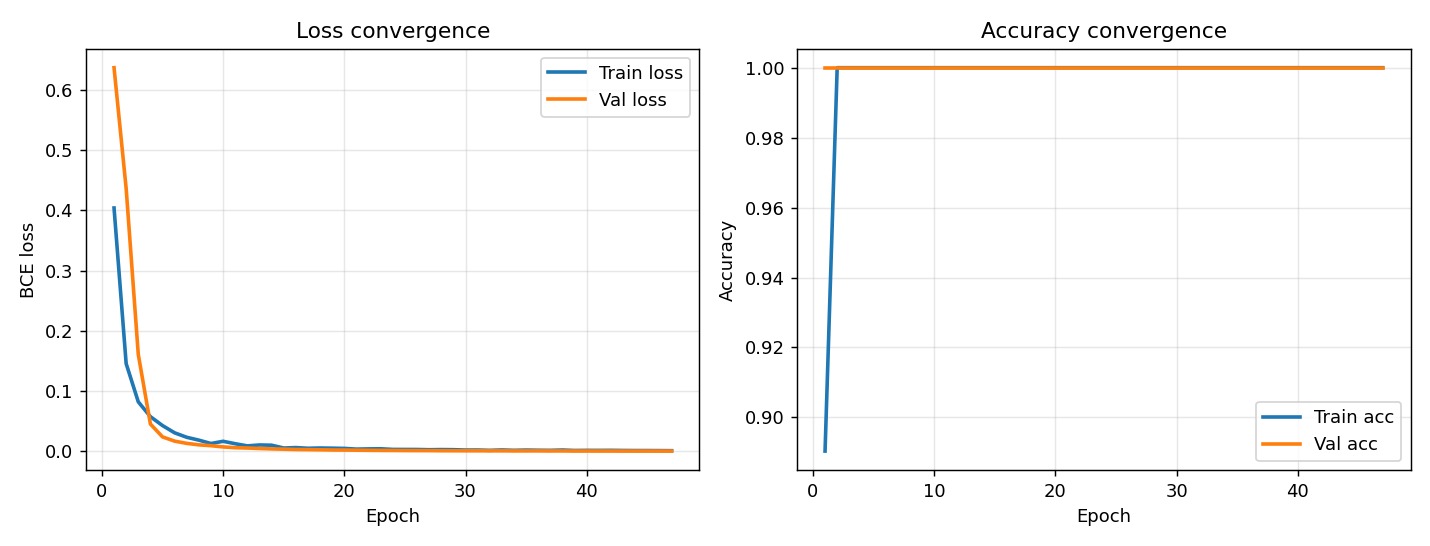

In [ ]:
import matplotlib.pyplot as pltepochs = range(1, len(history['train_loss'])+1)fig, axes = plt.subplots(1, 2, figsize=(11,4.2))axes[0].plot(epochs, history['train_loss'], label='Train loss')axes[0].plot(epochs, history['val_loss'], label='Val loss')axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE loss'); axes[0].set_title('Loss convergence')axes[0].legend(); axes[0].grid(alpha=0.3)axes[1].plot(epochs, history['train_acc'], label='Train acc')axes[1].plot(epochs, history['val_acc'], label='Val acc')axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].set_title('Accuracy convergence')axes[1].legend(); axes[1].grid(alpha=0.3)plt.tight_layout(); plt.show()

## 7. Test set evaluation

In [ ]:
test_loss, test_acc = evaluate(test_loader)print(f"Test loss: {test_loss:.4f}  Test accuracy: {test_acc:.4f}")model.eval()with torch.no_grad():    logits = model(torch.tensor(X_test).to(device))    probs = torch.sigmoid(logits).cpu().numpy()    preds = (probs > 0.5).astype(int)print(classification_report(y_test, preds, target_names=['negative','positive'], digits=3))print("Confusion matrix:\n", confusion_matrix(y_test, preds))

Test loss: 0.0004  Test accuracy: 1.0000              precision    recall  f1-score   support    negative      1.000     1.000     1.000        64    positive      1.000     1.000     1.000        65    accuracy                          1.000       129   macro avg      1.000     1.000     1.000       129weighted avg      1.000     1.000     1.000       129Confusion matrix: [[64  0] [ 0 65]]

## 8. Inference on genuinely unseen, hand-written sentencesNone of these five sentences were produced by the template generator — this is the more honest test of whether the model learned sentiment signal or just the templates.

In [ ]:
samples = [    "Honestly this exceeded what I paid for, works like a charm every day.",    "Complete waste of money, stopped working within a week and support never replied.",    "It's fine I guess, does the job but nothing special.",    "Absolutely thrilled with how smooth and reliable this has been so far!",    "Terrible experience from start to finish, would not recommend to anyone.",]X_new = vectorizer.transform(samples).toarray().astype(np.float32)with torch.no_grad():    logits = model(torch.tensor(X_new).to(device))    probs = torch.sigmoid(logits).cpu().numpy()for s, p in zip(samples, probs):    label = "POSITIVE" if p > 0.5 else "NEGATIVE"    conf = p if p > 0.5 else 1 - p    print(f"[{label}  conf={conf:.3f}]  {s}")

[POSITIVE  conf=0.991]  Honestly this exceeded what I paid for, works like a charm every day.[NEGATIVE  conf=0.992]  Complete waste of money, stopped working within a week and support never replied.[POSITIVE  conf=0.534]  It's fine I guess, does the job but nothing special.[POSITIVE  conf=0.793]  Absolutely thrilled with how smooth and reliable this has been so far![NEGATIVE  conf=0.991]  Terrible experience from start to finish, would not recommend to anyone.

## 9. Takeaways- 4/5 unseen sentences get the intuitively correct label with high confidence (0.79–0.99).- The genuinely ambiguous one — *"It's fine I guess, does the job but nothing special"* — gets the lowest confidence of the batch (0.534, barely past the 0.5 threshold). That's the model correctly signaling uncertainty rather than confidently guessing, which is a better sign of real generalization than the perfect training/test numbers in §7.- Train/val/test accuracy near 100% on templated data should not be read as "this model is production-ready" — it means the pipeline (vectorize → train with dropout/batchnorm → early stop → evaluate → do inference) is wired correctly end-to-end. Swap in a real-world labeled dataset (e.g. IMDB reviews or a Kaggle spam corpus) to get a meaningful benchmark number.